# 2  - E2E Machine Learning proiektua

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1 - Datuak lortu

* **California Housing Prices**: *Median house prices for California districts derived from the 1990 census.*

In [2]:
# Datu basearen esteka
url = "https://github.com/ageron/data/raw/main/housing.tgz"

# jaitsi eta deskonprimatu
!curl -L {url} | tar -xz

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0
100 438.5k 100 438.5k   0      0  1.82M      0                              0


* `!`: zerbitzariko ingurunean (*Linux shell*) exekutatuko den komandoa
* `curl` : *Transfer data from or to a server using URLs*
   * `-L` : *Follow re-location*  
* `|` (*pipe*): komando baten irteera hurrengo komandoaren sarrerarekin konektatu
* `tar` : *An archiving utility* (edukiak fitxategi bakarrean bildu)
   * `-x` : *Extract files from an archive*
   *  `-z` : *Filter the archive through gzip*

## 2 - Dataframe-a sortu eta bistaratu

CSV (Comma-Separated Values) formatuan dagoen taula **pandas**-eko *dataframe* bilakatu:

In [3]:
df = pd.read_csv("housing/housing.csv")

`df` dataframea bistaratu (pandas-ek zenbaki osoz osotutako indizea gehitzen dio):

In [4]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Dataframeak indexatzeko aukera ezberdinak ditugu. Indexazioaren emaitza ilara/zutabe bakarra bada, emaitza `Series` motako objektu bat izango da. Beste kasuetan emaitza `DataFrame` motako objektu bat izango da:

In [5]:
data = df["total_bedrooms"]
print(type(data))
data

<class 'pandas.Series'>


0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [6]:
data = df[["total_bedrooms","population"]]
print(type(data))
data

<class 'pandas.DataFrame'>


,total_bedrooms,population
0,129.0,322.0
1,1106.0,2401.0
2,190.0,496.0
3,235.0,558.0
4,280.0,565.0
...,...,...
20635,374.0,845.0
20636,150.0,356.0
20637,485.0,1007.0
20638,409.0,741.0


In [7]:
data = df.iloc[0]
print(type(data))
data

<class 'pandas.Series'>


longitude              -122.23
latitude                 37.88
housing_median_age        41.0
total_rooms              880.0
total_bedrooms           129.0
population               322.0
households               126.0
median_income           8.3252
median_house_value    452600.0
ocean_proximity       NEAR BAY
Name: 0, dtype: object

In [8]:
data = df.iloc[10:20] # indizeko balioak mantendu egiten dira
print(type(data))
data

<class 'pandas.DataFrame'>


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10,-122.26,37.85,52.0,2202.0,434.0,910.0,402.0,3.2031,281500.0,NEAR BAY
11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY
12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
13,-122.26,37.84,52.0,696.0,191.0,345.0,174.0,2.6736,191300.0,NEAR BAY
14,-122.26,37.85,52.0,2643.0,626.0,1212.0,620.0,1.9167,159200.0,NEAR BAY
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,NEAR BAY
16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
17,-122.27,37.85,52.0,1228.0,293.0,648.0,303.0,2.1202,155500.0,NEAR BAY
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,NEAR BAY
19,-122.27,37.84,52.0,1503.0,298.0,690.0,275.0,2.6033,162900.0,NEAR BAY


## 3 - Datuak aztertu

* **longitude/latitude** : barrutiaren kokapena
* **housing_median_age**: barrutiko etxeen antzinatasunaren mediana
* **total_rooms**: gela kopuru totala (barrutiko etxe guztientzat)
* **total_bedrooms**: logela kopuru totala (barrutiko etxe guztientzat)
* **population**: barrutiko biztanle kopurua
* **households**: barrutiko etxe kopurua
* **median_income**: barrutiko biztanleen diru-sarreren mediana
* **median_house_value**: barrutiko etxeen prezioen mediana
* **ocean_proximity**: ozeanoarekiko hurbiltasuna

[`dataframe.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) metodoak zutabeen laburpen sinple bat eskaintzen du:

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


[`dataframe.hist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) metodoak zutabeen histogramak marrazten ditu:

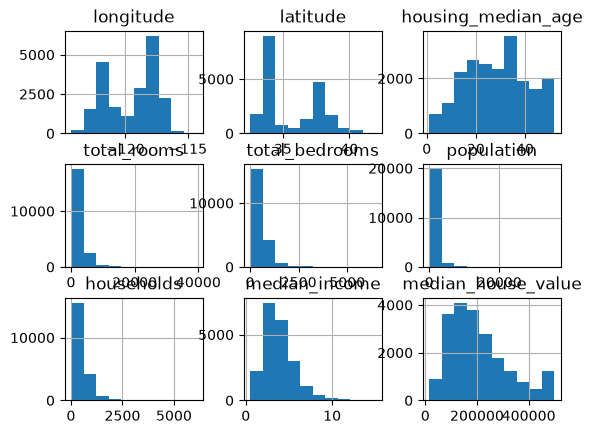

In [10]:
df.hist();

`df.hist();` vs `df.hist()` : Jupyter Notebook-ek gelaxkako azken adierazpenaren itzulera-balioa testu gisa erakusten du defektuz. `;` jartzea adierazpen horren irteera automatikoa ezkutatzen du.

`hist(..)` metodoaren argumentu batzuk:
* `bins`: Number of histogram bins to be used
* `figsize`: The size in inches of the figure to create

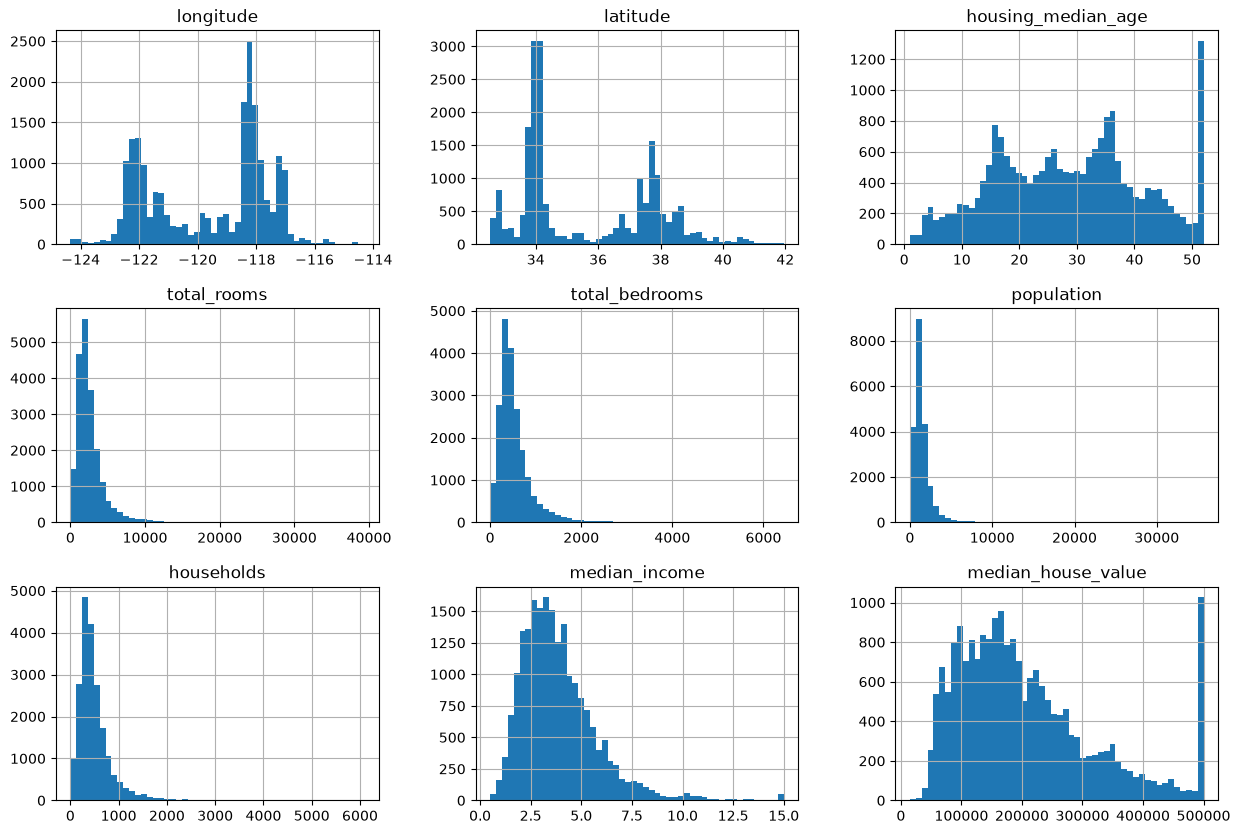

In [11]:
df.hist(bins=50, figsize=(15,10));

Histogramal behatzean:
* **housing_median_age**
    * $[1,52]$ tartera mugatua (52-n datu *arraroa*)
* **median_income**:
    * Eskala: ez dago dolarretan (\$10k)
    * $[0.5,15]$ tartera mugatua (\$150000etan datu *arraroa*)
* **median_house_value**
    * Eskala: dolarretan
    * $[15k,500k]$ tartera mugatua (\$500k-n datu *arraroa*) &rarr; helburu aldagaia bada, arazoa?
* Ezaugarriek eskala nahiko ezberdinak
* Orohar, banaketak ez dira simetrikoak (eskuineko alborapena dute) 

In [12]:
for c in ['housing_median_age', 'median_income', 'median_house_value']:
    print(f'{c} ∈ [{df[c].min()} , {df[c].max()}]')

housing_median_age ∈ [1.0 , 52.0]
median_income ∈ [0.4999 , 15.0001]
median_house_value ∈ [14999.0 , 500001.0]


Longitude/latitude ezaugarriak barrutien kokaguneak marrazteko erabil ditzakegu:

<Axes: xlabel='longitude', ylabel='latitude'>

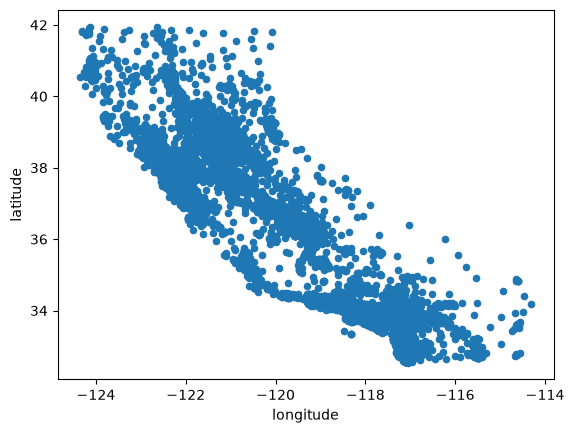

In [13]:
df.plot(x='longitude', y='latitude', kind='scatter')

Informazio gehiago gehitu dezakegu:
* Barruti bakoitzaren **populazioa**: puntuaren **tamaina**
* Batazbesteko etxeen **prezioa**: puntuaren **kolorea** 

<Axes: xlabel='longitude', ylabel='latitude'>

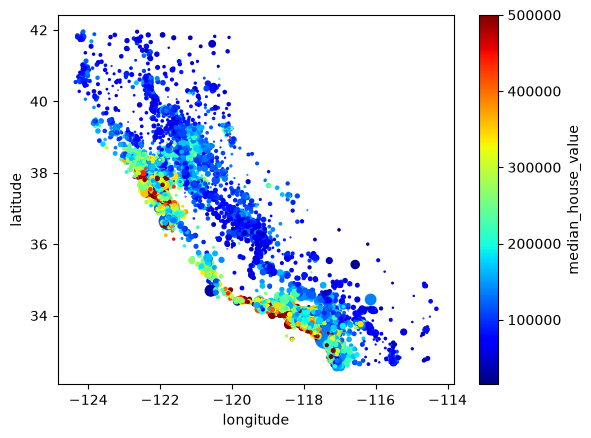

In [14]:
df.plot(
    kind='scatter',
    x='longitude', y='latitude',
    s=df['population']/200,
    c='median_house_value', cmap='jet', colorbar=True
)

Eta Californiako mapa batean kokatuko bagenu informazio guztia?

In [15]:
# irudiaren esteka
url = "https://github.com/mpenagar/Egungo-Programazio-Teknikak/blob/master/img/california.png?raw=true"
# jaitsi 
!curl -L {url} > california.png

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
100  17156 100  17156   0      0  40306      0                              0


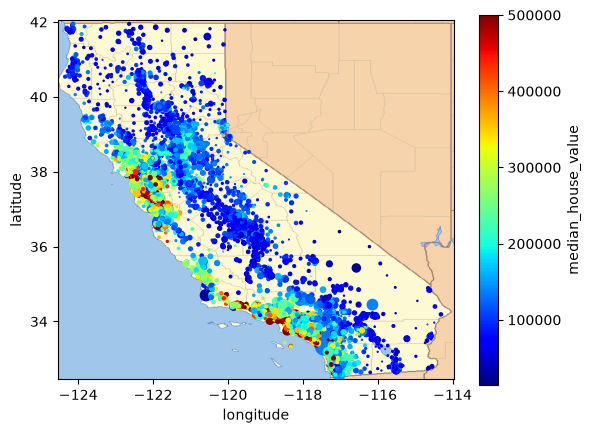

In [16]:
df.plot(
    kind='scatter',
    x='longitude', y='latitude',
    s=df['population']/200,
    c='median_house_value', cmap='jet', colorbar=True
)
california_img = plt.imread('california.png')
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.show()

## 4 - Train/Test banaketa egin

Testerako datuen %20a erreserbatuko dugu. *Scikit-learn*-eko `train_test_split()` funtzioa erabiliko dugu:

In [17]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)
print(f'{df.shape = }')
print(f'{train.shape = }')
print(f'{test.shape = }')
#train
#test

df.shape = (20640, 10)
train.shape = (16512, 10)
test.shape = (4128, 10)


* `random_state=...`: exekutatzen dugun bakoitzean sasi-auzazkotasun generatzaileak hazi berdina erabiliko du, **erreproduzigarritasuna** bermatuz.
* `42`: edozein balio izan daiteke ([El sentido de la vida, el universo y todo lo demás: 42](https://es.wikipedia.org/wiki/El_sentido_de_la_vida,_el_universo_y_todo_lo_dem%C3%A1s)) https://www.youtube.com/watch?v=W5dPnXaMcWw

Train/Test banaketa egitean, jatorrizko indizea mantentzen da:

In [18]:
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,NEAR OCEAN
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,NEAR OCEAN
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,NEAR BAY
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,<1H OCEAN
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND


`.reset_index(drop=True)` funtzioak indizea berritzen du.
* `drop=True` : defektuz indize zaharra ezaugarri gisa mantentzen du.

In [19]:
train.reset_index(drop=True).head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,NEAR OCEAN
1,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,NEAR OCEAN
2,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,NEAR BAY
3,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,<1H OCEAN
4,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND


In [20]:
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
#train
#test

## 5 - Aldagai iragarleak eta helburu-aldagaia ezberdindu 

Oraingoz:
* Helburu-aldagaia: **median_house_value**
* Aldagai iragarleak: beste guztiak

In [21]:
X_train = train.drop(columns=['median_house_value'])
y_train = train['median_house_value'].copy() # bertsio berrietan .copy() ez da beharrezkoa, Copy-on-Write
#X_train
#y_train

**Copy-on-Write**: `train['median_house_value']`-k zutabe originalaren *view* bat bueltatzen du: `y_train`-en aldaketak egitean, `train`-eko zutabean aldaketak egingo genituzke. Pandas-en bertsio berriek (≥3.0) *Copy-on-Write* propietatea dute, `y_train` aldatzera goazenean datuen kopia bat sortzen da eta `train`-eko zutabean ez da aldaketarik gertatzen. 

Entrenamendu-multzoan aplikatzen diren eraldaketa guztiak testean ere aplikatu behar dira, beraz errazena da DataFrame bati aplikatu beharreko eraldaketa guztiak funtzio baten bidez adieraztea:

In [22]:
def preprocessing(df):
    X = df.drop(columns=['median_house_value'])
    # y = df['median_house_value'].copy()
    # DataFrameak helburu-aldagairik ez balu...
    y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
    return X,y

X_train, y_train = preprocessing(train)
X_test, y_test = preprocessing(test)
print(f'{train.shape = }  {X_train.shape = }  {y_train.shape = }')
print(f'{test.shape = }  {X_test.shape = }  {y_test.shape = }')
#X_train
#y_train
#X_test
#y_test

train.shape = (16512, 10)  X_train.shape = (16512, 9)  y_train.shape = (16512,)
test.shape = (4128, 10)  X_test.shape = (4128, 9)  y_test.shape = (4128,)


## 7 - Ezaugarrien konbinaketa

Ezaugarrietako batzuk barruti bakoitzeko balio totalak dira (barrutian dauden etxe kopuruarekin handitzen dira) eta ez dute erabilgarritasun handirik barruti batetako ezaugarri gisa:

* **total_rooms**: gela kopuru totala (barrutiko etxe guztientzat)
* **total_bedrooms**: logela kopuru totala (barrutiko etxe guztientzat)

Zentzuzkoagoa litzateke etxebizitza baten batazbesteko gela eta logela kopurua izatea ezaugarria:
* **rooms_ph** (*average rooms per household*): `total_rooms/households`
* **bedrooms_ph** (*average rooms per household*): `total_bedrooms/households`

Ezaugarri originalak ezabatu ditzakegu:

In [23]:
def preprocessing(df):
    df = df.copy() # ematen diguten dataframe-a ez aldatzeko...
    
    df['rooms_ph'] = df['total_rooms'] / df['households']
    df['bedrooms_ph'] = df['total_bedrooms'] / df['households']
    df = df.drop(columns=['total_bedrooms','total_rooms'])
    
    X = df.drop(columns=['median_house_value'])
    y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
    return X,y

X_train, y_train = preprocessing(train)
X_test, y_test = preprocessing(test)
print(f'{train.shape = }  {X_train.shape = }  {y_train.shape = }')
print(f'{test.shape = }  {X_test.shape = }  {y_test.shape = }')
#X_train
#y_train
#X_test
#y_test

train.shape = (16512, 10)  X_train.shape = (16512, 9)  y_train.shape = (16512,)
test.shape = (4128, 10)  X_test.shape = (4128, 9)  y_test.shape = (4128,)


## 6 - Balio galduak 

Balio galduak edonon agertu daitezke:

In [24]:
X_train.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
population              0
households              0
median_income           0
ocean_proximity         0
rooms_ph                0
bedrooms_ph           163
dtype: int64

Test-eko datuetan zer gertatuko den ezin dugu aurrez jakin, hala ere hemen tranpa txiki bat egingo dugu:

In [25]:
X_test.isnull().sum()

longitude              0
latitude               0
housing_median_age     0
population             0
households             0
median_income          0
ocean_proximity        0
rooms_ph               0
bedrooms_ph           44
dtype: int64

Balio galdu hauen iturria *total_bedrooms* ezaugarria izan da:

In [26]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Aldagai kuantitatiboetan ohikoa da balio galduen ordezkapenean mediana erabiltzea.
* Mediana **train-eko datuetan zenbatetsi behar da**
* Bi fase:
   * Medianaren estimazioa (**train**) &rarr; aurreprozesatzearen barne parametro bat
   * Aurreprozesatzea aplikatzea (**train+test**)

**OHARRA:** Hau ezaugarri guztiekin egin beharko genuke, izan ere ezin dugu ziurtatu zer gerta daitekeen aurrerago. Hala ere, kasu honetan `bedrooms_ph` aldagaiean aztertuko dugu balio galduen problema.

*Scikit-learn*-ek eraldaketak doitzen/zenbatesten eta aplikatzen dituzten **transformer**-ak ditu. Orohar onako moduan erabiltzen dira:

```python
transformer = SomeTransformer()
transformer.fit(train_data)
train_data_new = transformer.transform(train_data)
test_data_new = transformer.transform(test_data)
```

Gure datuen aurreprozesatze guztiaz arduratzen den antzeko objektu bat sor genezake:

```python
class Preprocessor(object):
    def __init__(self):
        # fit() egitean doitu beharreko barne parametroak sortu
        ...
        
    def fit(self, df):
        # barne parametroak doitu
        ...
        return self # konbentzioz, fit-ek self bueltatzen du
        
    def transform(self, df):
        df = df.copy() # ematen diguten dataframe-a ez aldatzeko...
        # Egin beharreko transformazio guztiak aplikatu
        ...
        # X eta y bereiztu
        ...
        return X, y
```

Eta erabiltzeko:

```python
preprocessor = Preprocessor()
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)
```

### Preprocessor klasearen inplementazioaren arazoa

`rooms_ph`-ren mediana zenbatestera goazenean, datuak ez daude prest (`fit` `transform` aurretik exekutatzen da):
* `rooms_ph` eta `bedrooms_ph` **ez dira existitzen**

```python
class Preprocessor:
    def __init__(self):
        # fit() egitean doitu beharreko barne parametroak sortu
        self.bedrooms_ph_median = None
    
    def fit(self, df):
        # barne parametroak doitu
        self.bedrooms_ph_median = df['bedrooms_ph'].median()
        return self # konbentzioz, fit-ek self bueltatzen du
        
    def transform(self, df):
        df = df.copy() # ematen diguten dataframe-a ez aldatzeko...
        # Egin beharreko transformazio guztiak aplikatu
        df['rooms_ph'] = df['total_rooms'] / df['households']
        df['bedrooms_ph'] = df['total_bedrooms'] / df['households']
        df = df.drop(columns=['total_bedrooms','total_rooms'])
        df['bedrooms_ph'] = df['bedrooms_ph'].fillna(self.bedrooms_ph_median)
        # X eta y bereiztu
        X = df.drop(columns=['median_house_value'])
        y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
        return X, y
```

Bigarren transformazio fasearen (*Balio galduak*) barne parametroak doitzeko (`fit`) aurreko fasearen (*Ezaugarrien konbinaketa*) transformazioa dagoeneko aplikatua egon behar da. Orohar, $i$. fasearen barne parametroak doitzeko $1,2,\dots,i-1$ faseen transformazioa dagoeneko aplikatuta egotea behar da.

Problema hau ebazteko, transformazio fase bakoitza bere *transformer* clase propioarekin adierazi dezakegu eta aurreprozesatze guztia egingo duen `Preprocessor` *transformer*-a haien menpe jarri:

### 1. `FeatureCombinator` : Ezaugarrien konbinaketa

In [27]:
class FeatureCombinator:
    def __init__(self):
        pass
        
    def fit(self, df):
        return self
        
    def transform(self, df):
        df['rooms_ph'] = df['total_rooms'] / df['households']
        df['bedrooms_ph'] = df['total_bedrooms'] / df['households']
        df = df.drop(columns=['total_bedrooms','total_rooms'])
        return df

### 2. `MedianFiller` : Balio galduak

In [28]:
class MedianFiller:
    def __init__(self):
        self.bedrooms_ph_median = None
        
    def fit(self, df):
        self.bedrooms_ph_median = df['bedrooms_ph'].median()
        return self
        
    def transform(self, df):
        df['bedrooms_ph'] = df['bedrooms_ph'].fillna(self.bedrooms_ph_median)
        return df

### 3. `Preprocessor` : Aurreprozesatze osoa

In [29]:
class Preprocessor:
    def __init__(self, transformers):
        self.transformers = transformers
            
    def fit(self, df):
        df = df.copy()
        for t in self.transformers:
            # t.fit(df)
            # df = t.transform(df)
            df = t.fit(df).transform(df)
        return self
    
    def transform(self, df):
        df = df.copy()
        for t in self.transformers:
            df = t.transform(df)

        X = df.drop(columns=['median_house_value'])
        y = df['median_house_value'].copy() if 'median_house_value' in df.columns else None
        
        return X, y

In [30]:
preprocessor = Preprocessor([FeatureCombinator(), MedianFiller()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

print(f'df["total_bedrooms"] balio galduak: {df['total_bedrooms'].isnull().sum()}')
print(f'X_train["bedrooms_ph"] balio galduak: {X_train['bedrooms_ph'].isnull().sum()}')
print(f'X_test["bedrooms_ph"] balio galduak: {X_test['bedrooms_ph'].isnull().sum()}')
#X_train
#y_train
#X_test
#y_test

df["total_bedrooms"] balio galduak: 207
X_train["bedrooms_ph"] balio galduak: 0
X_test["bedrooms_ph"] balio galduak: 0


Aurreprosezatzea beste momenturen batean erabili nahiko bagenu, gorde egin beharko genuke nolabait. `joblib` liburutegia erabili dezakegu:

In [31]:
import joblib

# Aurreprosezatzailea fitxategi batean gorde
joblib.dump(preprocessor, "preprocessor.data")

['preprocessor.data']

Aurrerago, nahi dugunean berreskuratu dezakegu:

In [32]:
# Aurreprosezatzailea fitxategi batetik kargatu
preprocessor2 = joblib.load("preprocessor.data")

X_test2, y_test2 = preprocessor2.transform(test)
#X_test2
#y_test2

## 8 - Ezaugarri kategorikoak bektorizatu

Eredu askok ezaugarri kuantitatiboak ametitzen dituzte soilik. Datubaseko **ocean_proximity** ezaugarria kategorikoa da: 

In [33]:
df['ocean_proximity']

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: str

Eta denera 5 kategoria ezberdin ageri dira soilik:

In [34]:
#set(train['ocean_proximity'])
df['ocean_proximity'].unique()

<ArrowStringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

**One-Hot-Encoding**: $\{c_1, c_2, \dots , c_k\}$ kategoria edo balio posible dituen ezaugarri kategoriko bat aldagai kuantitatibo bilakatzeko modu sinple bat $k$ tamainako bektore bat sortzea da. Bektoreko posizio gehienen balioa $0$ izango da, bat izan ezik, aldagaiaren balioari dagokiona. Adibidez, aldagaiaren balioa $c_i$ denean, ordezkatuko dugun $v=[v_1,v_2,\dots,v_k]$ bektorearen balioa ondokoa da:
$$
v_j = \begin{cases} 
0, & j \ne i \\ 
1, & j = i 
\end{cases}
$$

Pandasek ba du ezaugarri kategorikoak erraz bektorizatzeko balio duen `pd.get_dummies()` funtzioa:

In [35]:
pd.get_dummies(df['ocean_proximity'], dtype=int)

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
20635,0,1,0,0,0
20636,0,1,0,0,0
20637,0,1,0,0,0
20638,0,1,0,0,0


In [36]:
pd.get_dummies(train, columns=['ocean_proximity'], dtype=int)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,0,0,0,0,1
1,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,0,0,0,0,1
2,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,0,0,0,1,0
3,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,1,0,0,0,0
4,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,-122.37,37.94,49.0,969.0,229.0,599.0,195.0,1.3167,71600.0,0,0,0,1,0
16508,-118.38,33.89,35.0,1778.0,330.0,732.0,312.0,6.5745,379300.0,1,0,0,0,0
16509,-119.33,36.28,16.0,2624.0,527.0,1077.0,520.0,2.1250,104200.0,0,1,0,0,0
16510,-117.19,34.08,22.0,2467.0,555.0,1567.0,494.0,2.6536,84700.0,0,1,0,0,0


Hala ere, eraldaketa hau hasera-haseratik egin beharko litzateke, izan ere test-eko azpimultzoan kategoriaren bat faltako balitz, gauza arraroak gerta litezke. Adibidez, gure datubasean ez daude `'ISLAND'` balioa duten adibide asko: 

In [37]:
print((df['ocean_proximity']=='ISLAND').sum())

5


eta kasualitatez denak entrenamendu azpimultzoan erori dira:

In [38]:
print(f'Entrenamenduan: {(train['ocean_proximity']=='ISLAND').sum()}')
print(f'Testean: {(test['ocean_proximity']=='ISLAND').sum()}')

Entrenamenduan: 5
Testean: 0


Hau dela eta, `pd.get_dummies()` funtzioa test-eko azpimultzoan aplikatzean, emaitzako dataframearen egitura ezberdina da (`15 columns` vs `16 columns`):

In [39]:
pd.get_dummies(test, columns=['ocean_proximity'], dtype=int)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,0,1,0,0
1,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,1,0,0,0
2,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,0,0,0,1
3,-118.44,34.05,18.0,4780.0,1192.0,1886.0,1036.0,4.4674,500001.0,1,0,0,0
4,-118.44,34.18,33.0,2127.0,414.0,1056.0,391.0,4.3750,286100.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4123,-121.92,40.52,13.0,4581.0,881.0,1799.0,734.0,2.2993,99500.0,0,1,0,0
4124,-122.08,37.68,26.0,2607.0,682.0,1401.0,607.0,2.6563,184100.0,0,0,1,0
4125,-119.00,35.39,42.0,2839.0,516.0,1203.0,487.0,3.7708,79400.0,0,1,0,0
4126,-117.92,33.63,39.0,1469.0,226.0,553.0,225.0,7.8496,490800.0,1,0,0,0


In [40]:
print(pd.get_dummies(train, columns=['ocean_proximity'], dtype=int).shape)
print(pd.get_dummies(test, columns=['ocean_proximity'], dtype=int).shape)

(16512, 14)
(4128, 13)


Egoera hau ekiditeko, *Scikik-learn*-en `OneHotEncoder` kodetzailea erabili dezakegu. Kodetzaile honek entrenamenduko datuetan doitu daiteke (existitzen diren klaseak aztertu) eta ondoren beste edozein daturekin erabili:

In [41]:
from sklearn.preprocessing import OneHotEncoder

# 1. Encoderra/Kodetzailea hasieratu
# sparse_output=False matrize dentsoa itzultzen du (beharrezkoa da Pandaserako)
# handle_unknown='ignore' testak kategoria berriak baditu, ez egin akatsik
# drop='first' lehenengo zutabea ezabatu erlazio linealik ez egoteko (dummy variable trap)
# feature_name_combiner=... sortutako zutabeen izenak ezartzen dituen funtzioa
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
    drop='first',
    feature_name_combiner=lambda column, cathegory : str(cathegory)
)

# Kodetzailearen emaitza Pandas-eko DataFrame izaten jarrai dezan
encoder.set_output(transform="pandas")

# 2. Encoderra doitu. OneHotEncoder-ak nx1 gisako matrize egitura espero du, df[['name']]
encoder.fit(X_train[['ocean_proximity']])

# 3. Kodetzailea aplikatu. OneHotEncoder-ak nx1 matrize egitura espero du, df[['name']]
encoder.transform(X_train[['ocean_proximity']]).head()

,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


* `df['col_name']` &rarr; `pandas.Series ($n$ tamainako bektore egitura)
* `df[['col_name']]` (fancy indexing) &rarr; `pandas.DataFrame` ($n \times 1$ tamainako matrize egitura)

In [42]:
print(f'{type(df['ocean_proximity']) = }')
print(f'{type(df[['ocean_proximity']]) = }')
print(f'{df['ocean_proximity'].shape = }')
print(f'{df[['ocean_proximity']].shape = }')

type(df['ocean_proximity']) = <class 'pandas.Series'>
type(df[['ocean_proximity']]) = <class 'pandas.DataFrame'>
df['ocean_proximity'].shape = (20640,)
df[['ocean_proximity']].shape = (20640, 1)


Sortutako zutabe berriak DataFrame zaharrarekin bildu behar dira eta *ocean_proximity* zutabea ezabatu:

In [43]:
df1 = X_train.drop(columns=['ocean_proximity'])
df2 = encoder.transform(X_train[['ocean_proximity']])
pd.concat([df1,df2], axis=1).head()

,longitude,latitude,housing_median_age,population,households,median_income,rooms_ph,bedrooms_ph,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-117.22,32.75,34.0,2654.0,1072.0,4.5878,5.597948,1.036381,0.0,0.0,0.0,1.0
1,-117.03,32.69,10.0,698.0,167.0,4.6648,5.395210,0.976048,0.0,0.0,0.0,1.0
2,-122.27,37.74,28.0,2974.0,1484.0,3.6875,4.655660,1.047170,0.0,0.0,1.0,0.0
3,-121.82,37.25,25.0,2178.0,650.0,5.1663,6.186154,0.975385,0.0,0.0,0.0,0.0
4,-115.98,33.32,8.0,63.0,24.0,1.4688,10.000000,1.916667,1.0,0.0,0.0,0.0


OneHotEncoderra aurreprozesatzearen fase bat gehiago izango da, **entrenamenduko datuekin doitu neharko dena**, `total_bedrooms_median` parametroarekin gertatzen zen moduan:

In [44]:
class CathegoryVectorizer:
    def __init__(self):
        self.ocean_proximity_encoder = OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
            drop='first',
            feature_name_combiner=lambda column, cathegory : str(cathegory)
        )
        self.ocean_proximity_encoder.set_output(transform="pandas")
        
    def fit(self, df):
        self.ocean_proximity_encoder.fit(df[['ocean_proximity']])
        return self
        
    def transform(self, df):
        df = pd.concat([
            df.drop(columns=['ocean_proximity']),
            self.ocean_proximity_encoder.transform(df[['ocean_proximity']])
        ], axis=1)
        return df

preprocessor = Preprocessor([FeatureCombinator(), MedianFiller(), CathegoryVectorizer()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

X_train
#y_train
#X_test
#y_test

,longitude,latitude,housing_median_age,population,households,median_income,rooms_ph,bedrooms_ph,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-117.22,32.75,34.0,2654.0,1072.0,4.5878,5.597948,1.036381,0.0,0.0,0.0,1.0
1,-117.03,32.69,10.0,698.0,167.0,4.6648,5.395210,0.976048,0.0,0.0,0.0,1.0
2,-122.27,37.74,28.0,2974.0,1484.0,3.6875,4.655660,1.047170,0.0,0.0,1.0,0.0
3,-121.82,37.25,25.0,2178.0,650.0,5.1663,6.186154,0.975385,0.0,0.0,0.0,0.0
4,-115.98,33.32,8.0,63.0,24.0,1.4688,10.000000,1.916667,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16507,-122.37,37.94,49.0,599.0,195.0,1.3167,4.969231,1.174359,0.0,0.0,1.0,0.0
16508,-118.38,33.89,35.0,732.0,312.0,6.5745,5.698718,1.057692,0.0,0.0,0.0,0.0
16509,-119.33,36.28,16.0,1077.0,520.0,2.1250,5.046154,1.013462,1.0,0.0,0.0,0.0
16510,-117.19,34.08,22.0,1567.0,494.0,2.6536,4.993927,1.123482,1.0,0.0,0.0,0.0


### Hausnarketa
Zentzuzkoa al da `'ocean_proximity'=='ISLAND'` duten 5 lagin horiek mantentzea? ML eredua gai izango ote da 5 lagin horiek duten egitura barneratzeko? Gure kasuan ez dio gehiegi ajola, guztiak entrenamenduan erori direlako, baina laginak baztertzea ere aukera bat da. 

In [45]:
print(f'Baztertuko diren laginak: {(df['ocean_proximity']=='ISLAND').sum()}')
print(f'{df.shape = }')
df = df[df['ocean_proximity']!='ISLAND']
print(f'ISLAND laginak DataFrame berrian: {(df['ocean_proximity']=='ISLAND').sum()}')
print(f'{df.shape = }')

Baztertuko diren laginak: 5
df.shape = (20640, 10)
ISLAND laginak DataFrame berrian: 0
df.shape = (20635, 10)


Eta haseratik pausu guztiak berriro eman:

In [46]:
train, test = train_test_split(df, test_size=0.2, random_state=42)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

preprocessor = Preprocessor([FeatureCombinator(), MedianFiller(), CathegoryVectorizer()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

#X_train
#y_train
#X_test
#y_test

## 9 - Balio arraroak topatu

Noizbehinka interesgarria da balio arrarorik ote dugun konprobatzea. 

In [47]:
X_train.drop(columns=['INLAND','NEAR BAY','NEAR OCEAN']).describe()

,longitude,latitude,housing_median_age,population,households,median_income,rooms_ph,bedrooms_ph
count,16508.000000,16508.000000,16508.000000,16508.000000,16508.000000,16508.000000,16508.000000,16508.000000
mean,-119.570202,35.632099,28.585534,1432.443421,501.371699,3.869512,5.423336,1.095158
std,2.004952,2.134130,12.572533,1144.752748,382.454493,1.903084,2.289802,0.443625
min,-124.350000,32.540000,1.000000,3.000000,1.000000,0.499900,0.888889,0.333333
25%,-121.800000,33.930000,18.000000,788.750000,281.000000,2.562500,4.443181,1.006623
50%,-118.500000,34.260000,29.000000,1170.500000,411.000000,3.532550,5.233333,1.048558
75%,-118.010000,37.712500,37.000000,1732.000000,607.000000,4.740400,6.047952,1.098039
max,-114.470000,41.950000,52.000000,35682.000000,6082.000000,15.000100,132.533333,34.066667


Lau kasu aztertuko ditugu:
* $max(bedrooms\_ph)=34.066667$
* $max(rooms\_ph)=132.533333$
* $min(bedrooms\_ph)=0.333333$
* $min(rooms\_ph)=0.888889$

Maximo/minimoak topatzeko `argmax()` eta `argmin()` funtzioak erabil ditzakegu

### 1. `max(bedrooms_ph)=34.066667`

In [48]:
i = X_train['bedrooms_ph'].argmax()
print(f'indizea: {i}')
train.iloc[i]

indizea: 5231


longitude              -120.08
latitude                  38.8
housing_median_age        34.0
total_rooms             1988.0
total_bedrooms           511.0
population                36.0
households                15.0
median_income            4.625
median_house_value    162500.0
ocean_proximity         INLAND
Name: 5231, dtype: object

Apur bat arraroa dirudi 15 etxeetan 511 logela egotea...

### 2. `max(rooms_ph)=132.533333`

In [49]:
i = X_train['rooms_ph'].argmax()
print(f'indizea: {i}')
train.iloc[i]

indizea: 5231


longitude              -120.08
latitude                  38.8
housing_median_age        34.0
total_rooms             1988.0
total_bedrooms           511.0
population                36.0
households                15.0
median_income            4.625
median_house_value    162500.0
ocean_proximity         INLAND
Name: 5231, dtype: object

Apur bat arraroa ere, 15 etxeetan 1988 gela egotea... Ohar bat: aurreko bi laginak berdinak dira, (`indizea: 5231`).

### 3. `min(bedrooms_ph)=0.333333`

In [50]:
i = X_train['bedrooms_ph'].argmin()
print(f'indizea: {i}')
train.iloc[i]

indizea: 15257


longitude                -119.23
latitude                   34.25
housing_median_age          28.0
total_rooms                 26.0
total_bedrooms               3.0
population                  29.0
households                   9.0
median_income                8.0
median_house_value      275000.0
ocean_proximity       NEAR OCEAN
Name: 15257, dtype: object

9 etxebizitza, baina denera 3 logela. Logelarik gabeko etxebizitzak?

### 4. `min(rooms_ph)=0.888889`

In [51]:
i = X_train['rooms_ph'].argmin()
print(f'indizea: {i}')
train.iloc[i]

indizea: 1976


longitude                -118.21
latitude                   33.79
housing_median_age          33.0
total_rooms                 32.0
total_bedrooms              18.0
population                  96.0
households                  36.0
median_income             4.5938
median_house_value      112500.0
ocean_proximity       NEAR OCEAN
Name: 1976, dtype: object

36 etxebizitza, baina denera 32 gela. Gelarik gabeko etxebizitzak?

### Hausnarketa
Halako egoeretan datuak zuzenak ote diren galdetu beharko genioke gure buruari. Erroreak dituzten lagin guztiekin zerbait egin beharko genuke:
* Balioak ordezkatu
* Laginak baztertu

Kasu honetan, datuetan errorerik ez dagoela suposatuko dugu.

## 10 - Ezaugarri kuantitatiboak estandarizatu

Eredu batzuk ezaugarri kuantitatiboen eskalarekiko sentikortasun handia izan dezakete. 

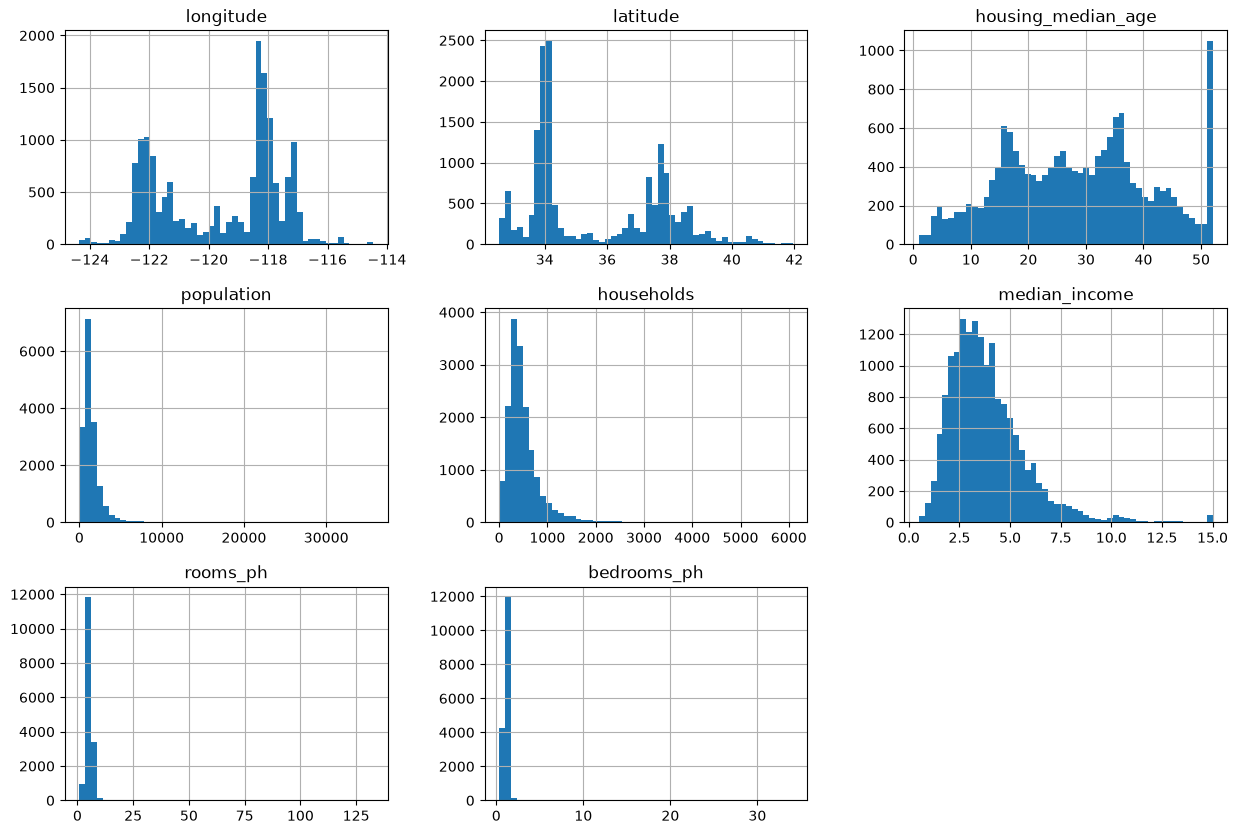

In [52]:
X_train.drop(columns=['INLAND','NEAR BAY','NEAR OCEAN']).hist(bins=50, figsize=(15,10));

**Estandarizazioa** (*Z-score*): Datuak eraldatzen ditu, 0 batez bestekoa eta 1 desbiderapen estandarra izan dezaten. $\mu$ datuen batez bestekoa bada eta $\sigma$ haien desbiderapen estandarra, orduan estandarizazioak ondoko transformazioa aplikatzen du:

$$x' = \frac{x - \mu}{\sigma}$$

Noiz erabili ohi da:
* Datuen banaketa normal baten araberakoak direnean.
* Ereduak banaketa normal bat espero duenean (**KONTUZ**, datuak gaussiarrak ez badira, emaitza ez da gausiarra izango)

*Scikit-learn*-eko StandardScaler erabili dezakegu estandarizazio transformazio bat zenbatetsi (entrenamenduan) eta edozein datu berritan aplikatzeko:

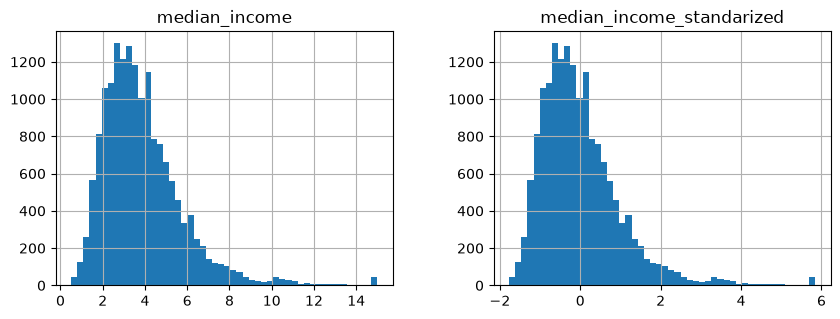

In [53]:
from sklearn.preprocessing import StandardScaler

df_tmp = X_train[['median_income']]
scaler = StandardScaler() 
scaler.fit(df_tmp)
df_tmp['median_income_standarized'] = scaler.transform(df_tmp)
df_tmp.hist(bins=50, figsize=(10,3.3));

In [54]:
X_train.iloc[0]

longitude             -117.950000
latitude                33.930000
housing_median_age      37.000000
population            1904.000000
households             630.000000
median_income            2.612300
rooms_ph                 4.179365
bedrooms_ph              1.000000
INLAND                   0.000000
NEAR BAY                 0.000000
NEAR OCEAN               0.000000
Name: 0, dtype: float64

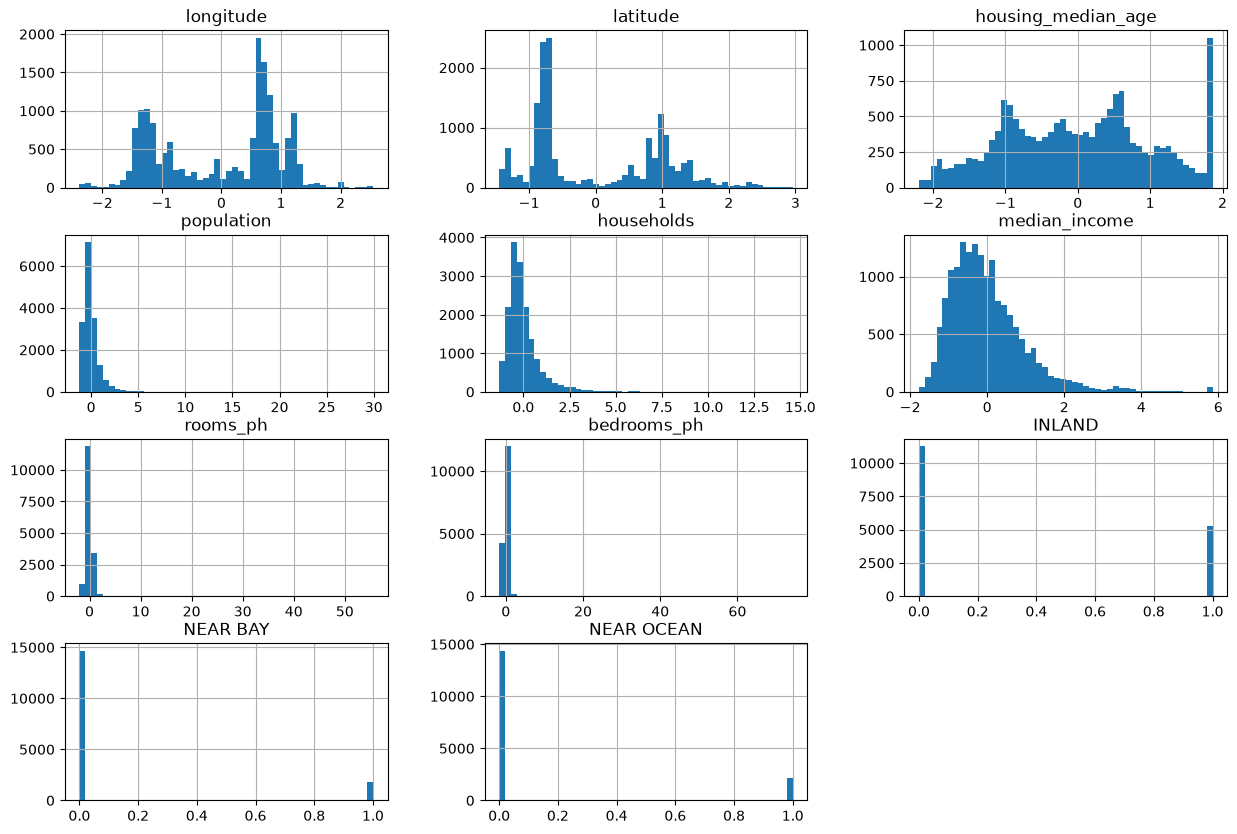

In [55]:
class Standarizer:
    def __init__(self):
        columns = ['longitude','latitude','housing_median_age','population','households','median_income','rooms_ph','bedrooms_ph']
        self.standarizers = {column:StandardScaler() for column in columns}
        
    def fit(self, df):
        for column,scaler in self.standarizers.items():
            scaler.fit(df[[column]])
        return self
        
    def transform(self, df):
        for column,scaler in self.standarizers.items():
            df[column] = scaler.transform(df[[column]])
        return df

preprocessor = Preprocessor([FeatureCombinator(), MedianFiller(), CathegoryVectorizer(), Standarizer()])
preprocessor.fit(train)
X_train, y_train = preprocessor.transform(train)
X_test, y_test = preprocessor.transform(test)

X_train.hist(bins=50, figsize=(15,10));
#X_train
#y_train
#X_test
#y_test

### Hausnarketa
Helburu aldagaia ez dugu estandarizatu:

array([[<Axes: title={'center': 'median_house_value'}>]], dtype=object)

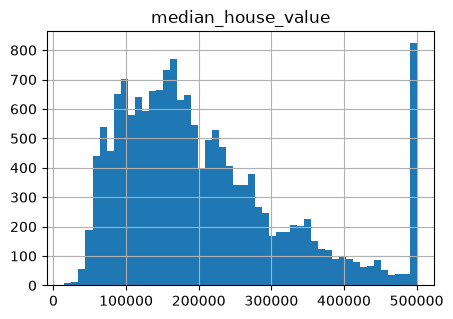

In [56]:
pd.DataFrame(y_train).hist(bins=50, figsize=(5,3.3))

Hau arazo bat izan liteke eredu batzuentzat. Beste ezaugarri kuantitatiboekin jokatu dugun moduan, estandarizazio bat aplikatzea zentzuzkoa da, dena den horrek apur bat zailtzen du emaitzen interpretazioa eta beraz ez dugu egingo (estandarizazioa transformazio itzulgarria da, ez legoke arazo larririk).

## 11 - Ereduak sortu, doitu eta ebaluatu

Atal honetan `ml_course` moduluak eskaintzen dizkigun bi erregresio eredu erabiliko ditugu:
* `SimpleRegressor`: *A really simple regression model without hyper-parameters*
* `ComplexRegressor`: *A somehow complex regression model with some hyper-parameters*

Modulua instalatu eta bi ereduak inportatu:

In [57]:
!pip install git+https://github.com/mpenagar/ml_course.git
import ml_course
from ml_course import SimpleRegressor, ComplexRegressor

  Cloning https://github.com/mpenagar/ml_course.git to /tmp/pip-req-build-f7s00yrk
  Running command git clone --filter=blob:none --quiet https://github.com/mpenagar/ml_course.git /tmp/pip-req-build-f7s00yrk
  Resolved https://github.com/mpenagar/ml_course.git to commit 5f2b086d71ff4ba960aad3d46b7eddb8d5f25cd8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [58]:
#?SimpleRegressor

In [59]:
#?ComplexRegressor

Aurrerago erabiliko ditugun *Scikt-learn*-eko ereduek (`ml_course` moduluko ereduek bezalaxe) erabilera patroi sinple bat dute:

```python
model = Model(param1=, param2=, ...)  # 1 - Eredua sortu/hasieratu konfigurazio-parametroak ezarriz
model.fit(X, y)                       # 2 - Eredua doitu (barne-parametroak zenbatetsi)
y_predict = model.predict(X)          # 3 - Helburu-aldagaia iragarri
```

Gure kasuan, eta oraingoz ereduen konfigurazio-parametroak (**hiperparametroak**, *hyperparameters*) alde batera utziko ditugunez, baina entrenamenduko eta testeko datuak bananduta ditugunez, ondokoa egin dezakegu edozein eredurekin:

```python
model = Model(param1=, param2=, ...)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
```

`SimpleRegressor` ereduarentzat:

In [60]:
model = SimpleRegressor()
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

Ereduaren errendimendua aztertu aurretik, lortutako iragarpenen eta benetako balioen banaketak aztertu ditzakegu:

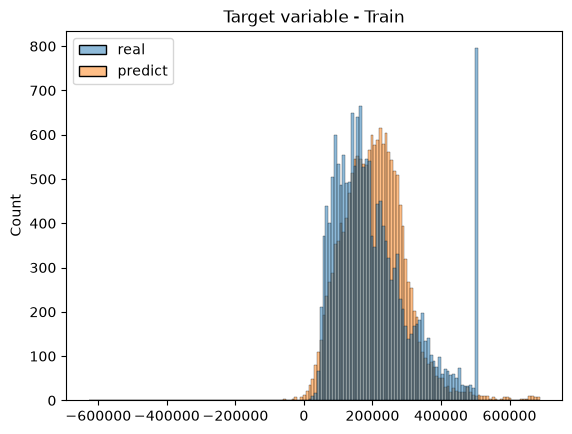

In [61]:
y_train_df = pd.DataFrame({
    'real':y_train,
    'predict':y_train_predict,
})
sns.histplot(y_train_df)
plt.title('Target variable - Train');

Hainbat ohar:
* Eredua balio negatiboak iragartzeko gai da...
* Eredua entrenamenduko \$500k-etako atalasea gainditzeko gai da

Test-eko azpimultzoan portaera berdina atzematen da:

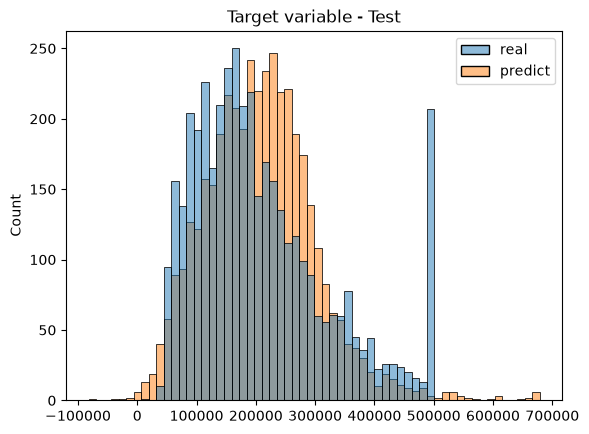

In [62]:
y_test_df = pd.DataFrame({
    'real':y_test,
    'predict':y_test_predict
})
sns.histplot(y_test_df)
plt.title('Target variable - Test');

Behin emaitzak ditugula, iragarpenean izandako **errorea** zein izan den neurtu behar dugu. Errore honek gure ereduaren **Errendimendua** adieraziko du.  

### Errore koadratikoaren batez bestekoaren erroa (RMSE, *Root Mean Squared Error*)

Erregresio-atazetan eredu baten akatsa edo desbideratzea neurtzeko metrikarik erabiliena da. Ereduaren iragarpenen ($\hat{y}_i$) eta benetako balioen ($y_i$) arteko diferentzien distantzia (errorea) neurtzen du:

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$

Interpretazio erraz bat:

* **Akats handiekiko sentsibilitatea**: Desbideratzeak berretzen dituenez, RMSEak zigor handia ezartzen die akats handiei. Zenbat eta baxuagoa izan balioa, orduan eta zehatzagoa da eredua.
* Erro karratua egitean, lortutako emaitza **helburu-aldagaiaren unitate berdinetan** adierazten da ( etxebizitzen prezioa dolarretan badago, RMSEa ere dolarretan egongo da).

*Scikit-learn*-ek RMSE kalkulatzen duen `root_mean_squared_error` eskaintzen digu:

In [63]:
from sklearn.metrics import root_mean_squared_error

print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE: ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $68506.55
Test  RMSE: $68567.85


Baina \$68k-etako errore bat... handia ala txikia al da? Konparaketak egin ahal izateko, interesgarria da *Baseline* erreferentzia-eredu bat izatea:
* **Ahalik eta sinpleenak** izan behar dira (*non-informative*), gure eredu *adimentsuarekin* konparatzeko.
* *Baseline* ereduarekiko **ezberdintasun txikia** &rarr; gure eredua ez da gai datuetan dagoen informazioa bereganatzeko.

Gure atazaren kasuan, adibidez, beti prezio berdina iragartzen duen eredu bat, *baseline* aproposa izan liteke.
* Zein balio, ordea?
* Entrenamenduan ikusitako *tarteto* balio bat &rarr; **mediana**.  

In [64]:
y_median = y_train.median()
y_train_predict = np.full(y_train.shape,y_median)
y_test_predict = np.full(y_test.shape,y_median)

In [65]:
print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE:  ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $118546.68
Test  RMSE:  $119421.24


Tira, badirudi ereduak zerbait ikasi duela!

Emaitzak taula batean jar ditzakegu:

| System          | $\mathbf{RMSE_{train}}$ | $\mathbf{RMSE_{test}}$ |
|-----------------|---------------:|---------------:|
| **Baseline**        |      118546.68 |      119421.24 |
| **SimpleRegressor** |       68506.55 |       68567.85 |

Bigarren ereduarekin, `ComplexRegressor`, gauza bera egin dezakegu: 

In [66]:
model = ComplexRegressor()
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

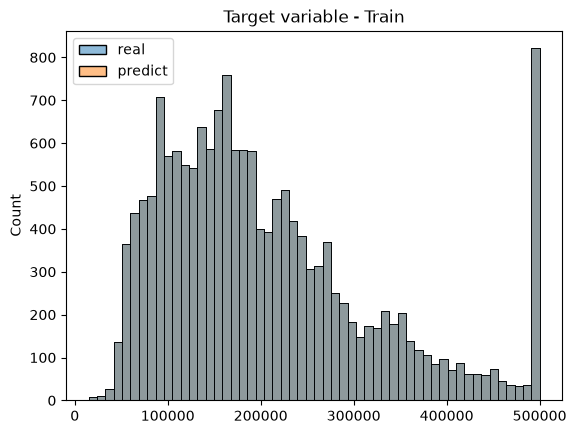

In [67]:
y_train_df = pd.DataFrame({
    'real':y_train,
    'predict':y_train_predict,
})
sns.histplot(y_train_df)
plt.title('Target variable - Train');

Zer gertatzen da hemen?
* Zergatik ez da iragarpenik ikusten?
* Nola da posible balio errealen histogramak iragarritako balioen histograma izkutatzea?
* Guztiz berdinak al dira?

Ea zer gertatu den testeko datuekin:

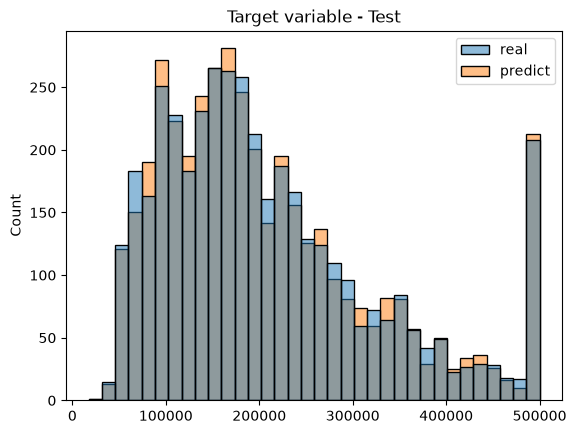

In [68]:
y_test_df = pd.DataFrame({
    'real':y_test,
    'predict':y_test_predict
})
sns.histplot(y_test_df)
plt.title('Target variable - Test');

Testeko datuetan zerbait ikusten da... Ereduak nahiko ongi asmatzen duela dirudi, ezta?

In [69]:
print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE: ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $0.00
Test  RMSE: $69396.94


Bitxia:
* Entrenamenduko errorea: **\$0**
* Testeko errorea: **\$69526.17** , `SimpleRegressor` ereduarena baina handiagoa.

&rarr; **Gaindoikuntza** (*Overfitting*)

Laburbilduz, badirudi eredu onena `SimpleRegressor` dela:

| System          | $\mathbf{RMSE_{train}}$ | $\mathbf{RMSE_{test}}$ |
|-----------------|---------------:|---------------:|
| **Baseline**         |      118546.68 |      119421.24 |
| **SimpleRegressor**  |       68506.55 |       **68567.85** |
| **ComplexRegressor** |           0.00 |       69526.17 |

### Hausnarketa
**Errendimendu-neurri** gisa RMSE (*Root Mean Squared Error*) erabili dugu. Baina eta zein izan da ereduek erabilitako $\mathcal{L}$ **Galera-funtzioa**?

Erregresio ereduetan, ohikoa da galera funtzioa **Errore Koadratikoaren Batez bestekoa** (MSE, *Mean Squared Error*) izatea. Ereduaren dokumentazioak kontrakoa esaten ez badu, beti suposa dezakegu ereduaren barne parametroak MSE minimizatuz doitzen direla:

$$\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}} \sum_{i=1}^{N} \mathcal{L}(y_i, \hat{y}_i) = \arg\min_{\boldsymbol{\theta}} MSE(y_i, \hat{y}_i)$$

Eta $RMSE = \sqrt{MSE}$ denez,

$$\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}} RMSE(y_i, \hat{y}_i)^2 = \arg\min_{\boldsymbol{\theta}} RMSE(y_i, \hat{y}_i)$$

Eta beraz, <u>Errendimendu-neurria eta Galera-funtzioa bat datoz</u>.

## 12 - Ereduen hiperparametroak doitzen

Ereduek argumentuen bidez ezartzen diren konfigurazio-parametroak izan ditzakete. Parametro hauek ereduaren doitze prozesua kontrolatzen dute eta haren errendimenduan aldaketak sor ditzakete. Konfigurazio-parametro hauek **hiperparametro** izenaz ezagunak dira: 

```python
model = Model(param1=, param2=, ...)  # eredua hasieratu aukeratutako hiperparametroekin
```

Gure bi ereduetatik, soilik `ComplexRegressor` ereduak eskaintzen dizkigu hiperparametroak:

In [70]:
#help(ComplexRegressor)

```
  Parameters
  ----------
  complexity : int, default=None
      Controls the maximum complexity of the model's internal structure. A higher value
      allows the model to learn more intricate patterns from the training data, but it
      heavily increases the risk of overfitting (memorizing the specific training
      examples instead of learning the general trend). If None, there is no limit on
      how complex the model can become (use with caution!).

  min_split_size : int, default=2
      The minimum amount of data points required before the model is allowed to divide
      a group into even smaller pieces. Increasing this value stops the model from
      creating overly complex and specific rules for very small sets of data.

  random_state : int, default=None
      Controls the randomness of the estimator. To obtain a deterministic behaviour
      during fitting, random_state has to be fixed to an integer
```

Badirudi `complexity` eta `min_split_size` hiperparametroen defektuzko balioak aurrez ikusitako gaindoikuntzaren  (*Overfitting*) iturria izan daitezkeela. Egin dezagun froga sinple bat: 

In [71]:
model = ComplexRegressor(complexity=10, min_split_size=10, random_state=42)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE: ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $48001.08
Test  RMSE: $60805.46


* Entrenamenduko errorea: 0-tik 48001.08-ra igo da
* Testeko errorea: 69526.17-tik 60833.57-ra jeitsi da, orain arteko emaitzarik hoberena!

Hala ere, bi arazo berri sortzen zaizkigu:
1. Bi hiperparametroren konbinaketa optimoa topatu behar dugu
2. Ezin ditugu testeko datuak erabili konbinaketa hoberena zein izango ote den erabakitzeko, eta entrenamendua erabiltzen badugu, ez dugu aukeraketa egokia egingo (goidoikuntza).

## 13 - Baliozkotze azpimultzoa

Testeko datuak erabili ezin ditzakegunez, aukera argi bat entrenamenduko datuak berriro bi azpimultzotan banatzea litzateke:
* **X_train2, y_train2**: eredua entrenatzeko erabiliko duguna
* **X_valid, y_valid**: baliozkotze azpimultzoa, test azpimultzoa balitz bezala, hiperparametro konbinaketa hoberena aukeratzeko erabiliko duguna.

In [72]:
X_train2, X_valid = train_test_split(X_train, test_size=0.2, random_state=42)
y_train2, y_valid = train_test_split(y_train, test_size=0.2, random_state=42)
print(f'{X_train.shape = }')
print(f'{X_train2.shape = }')
print(f'{X_valid.shape = }')
print(f'{X_test.shape = }')

X_train.shape = (16508, 11)
X_train2.shape = (13206, 11)
X_valid.shape = (3302, 11)
X_test.shape = (4127, 11)


**OHARRA:** `X_train,y_train` aldagaietatik abiatzen bagara, **beharrezkoa da** `random_state` argumentuaren balioa berdina izatea, datuen koherentzia bermatzeko. Hau bera `train` aldagaiatik abiatuz egin izan bagenu, ez legoke arrisku hau (`X,y` banaketa aurreprozesatzeak egingo luke):

```python
train2, valid = train_test_split(train, test_size=0.2, random_state=42)
X_train2, y_train2 = preprocessor.transform(train2)
X_valid, y_valid = preprocessor.transform(valid)
```

## 14 - Hiperparametroen optimizazioa (*Grid Search*)

Baliozkotze azpimultzoa definituta dugularik, hiperparametroen edozein konbinaketak izango duen errendimendua bertan neurtu dezakegu. Hala er, orohar, **hiperparametroen bilaketa espazioa mugagabea izango da**. Hau dela eta, konbinaketa kopuru finitu batekin konformatu beharko gara.

Hiperparametro bakoitzarentzat balio multzo finitu bat definitzen badugu, konbinaketa guztiek sareta (*grid*) bat osotuko dute. Sareta horretako konbinaketa bakoitzarekin eredua doitu (`train2` erabiliz) eta bere errendimendua neurtu dezakegu (`valid` erabiliz). Hiperparametroak optimizatzeko prozesu honi **Sareta bidezko Bilaketa** (*Grid Search*) deritzo.

Bilaketa sareta hiztegi baten bidez adierazi dezakegu, gakoak parametro izenak izanik eta balioak parametroak har ditzakeen balio multzo finitua adierazten duen zerrenda:

```python
grid = {
    'param1` : [value1, value2, ...] ,
    'param2` : [value1, value2, ...] ,
    ...
    'paramk` : [value1, value2, ...]
}    

Sortu dezagun lehenenik aurreko `grid` moduko hiztegi bat jaso eta konbinaketa guztiak dituen hiztegi zerrenda bueltatuko duen funtzioa:

In [73]:
def expand_grid(grid):
    if not grid:
        return [{}]

    grid = grid.copy()
    name, values = grid.popitem()   
    other_expanded = expand_grid(grid)
    
    result = []
    for v in values:
        for combo in other_expanded:
            result.append({**combo, name: v})
            
    return result

Froga dezagun adibide sinple batekin

In [74]:
x = {'a': [1, 2], 'b': [3], 'c': [4, 5, 6]}

for d in expand_grid(x):
    print(d)    

{'a': 1, 'b': 3, 'c': 4}
{'a': 2, 'b': 3, 'c': 4}
{'a': 1, 'b': 3, 'c': 5}
{'a': 2, 'b': 3, 'c': 5}
{'a': 1, 'b': 3, 'c': 6}
{'a': 2, 'b': 3, 'c': 6}


`expand_grid()` funtzioa dugularik, egin behar dugun guztia konbinaketak banan banan frogatzea besterik ez da:

In [75]:
def grid_search(model_class, grid, X_train, y_train, X_valid, y_valid):
    best_params = None
    best_rmse = np.inf
    for params in expand_grid(grid):
        model = model_class(**params)
        model.fit(X_train, y_train)
        y_valid_predict = model.predict(X_valid)
        rmse = root_mean_squared_error(y_valid, y_valid_predict)
        print(f'{params=}  RMSE: {rmse:.2f}')
        if rmse < best_rmse :
            best_rmse = rmse
            best_params = params
    return best_params, best_rmse

In [76]:
grid = {
    'complexity' : [5,10,15,20] ,
    'min_split_size' : [2, 4, 8, 16, 32, 64] ,
    'random_state' : [42]
}

best_params, best_rmse = grid_search(ComplexRegressor, grid, X_train2, y_train2, X_valid, y_valid)
print(f'{best_params = }')
print(f'{best_rmse = }')

params={'complexity': 5, 'min_split_size': 2, 'random_state': 42}  RMSE: 69919.04
params={'complexity': 10, 'min_split_size': 2, 'random_state': 42}  RMSE: 64602.80
params={'complexity': 15, 'min_split_size': 2, 'random_state': 42}  RMSE: 67934.40
params={'complexity': 20, 'min_split_size': 2, 'random_state': 42}  RMSE: 71198.04
params={'complexity': 5, 'min_split_size': 4, 'random_state': 42}  RMSE: 69919.04
params={'complexity': 10, 'min_split_size': 4, 'random_state': 42}  RMSE: 64871.89
params={'complexity': 15, 'min_split_size': 4, 'random_state': 42}  RMSE: 67828.81
params={'complexity': 20, 'min_split_size': 4, 'random_state': 42}  RMSE: 69735.82
params={'complexity': 5, 'min_split_size': 8, 'random_state': 42}  RMSE: 69919.04
params={'complexity': 10, 'min_split_size': 8, 'random_state': 42}  RMSE: 63468.45
params={'complexity': 15, 'min_split_size': 8, 'random_state': 42}  RMSE: 65684.15
params={'complexity': 20, 'min_split_size': 8, 'random_state': 42}  RMSE: 66797.45
params=

Test azpimultzoa ikutzen ari ez garenez, nahi dugun adina saiakera egin ditzakegu, bilaketa-saretako tarteak berdefinituz:

In [77]:
grid = {
    'complexity' : [13,14,15,16,17] ,
    'min_split_size' : [40,50,64,80,90] ,
    'random_state' : [42]
}

best_params, best_rmse = grid_search(ComplexRegressor, grid, X_train2, y_train2, X_valid, y_valid)
print(f'{best_params = }')
print(f'{best_rmse = }')

params={'complexity': 13, 'min_split_size': 40, 'random_state': 42}  RMSE: 60812.08
params={'complexity': 14, 'min_split_size': 40, 'random_state': 42}  RMSE: 60575.36
params={'complexity': 15, 'min_split_size': 40, 'random_state': 42}  RMSE: 60231.51
params={'complexity': 16, 'min_split_size': 40, 'random_state': 42}  RMSE: 60377.62
params={'complexity': 17, 'min_split_size': 40, 'random_state': 42}  RMSE: 60337.53
params={'complexity': 13, 'min_split_size': 50, 'random_state': 42}  RMSE: 60254.65
params={'complexity': 14, 'min_split_size': 50, 'random_state': 42}  RMSE: 59698.64
params={'complexity': 15, 'min_split_size': 50, 'random_state': 42}  RMSE: 59793.35
params={'complexity': 16, 'min_split_size': 50, 'random_state': 42}  RMSE: 59671.42
params={'complexity': 17, 'min_split_size': 50, 'random_state': 42}  RMSE: 59757.46
params={'complexity': 13, 'min_split_size': 64, 'random_state': 42}  RMSE: 60912.88
params={'complexity': 14, 'min_split_size': 64, 'random_state': 42}  RMSE: 6

In [78]:
grid = {
    'complexity' : [15,16,17] ,
    'min_split_size' : [45,47,50,52,55] ,
    'random_state' : [42]
}

best_params, best_rmse = grid_search(ComplexRegressor, grid, X_train2, y_train2, X_valid, y_valid)
print(f'{best_params = }')
print(f'{best_rmse = }')

params={'complexity': 15, 'min_split_size': 45, 'random_state': 42}  RMSE: 59937.21
params={'complexity': 16, 'min_split_size': 45, 'random_state': 42}  RMSE: 59931.65
params={'complexity': 17, 'min_split_size': 45, 'random_state': 42}  RMSE: 60100.63
params={'complexity': 15, 'min_split_size': 47, 'random_state': 42}  RMSE: 59729.30
params={'complexity': 16, 'min_split_size': 47, 'random_state': 42}  RMSE: 59732.19
params={'complexity': 17, 'min_split_size': 47, 'random_state': 42}  RMSE: 59819.24
params={'complexity': 15, 'min_split_size': 50, 'random_state': 42}  RMSE: 59793.35
params={'complexity': 16, 'min_split_size': 50, 'random_state': 42}  RMSE: 59671.42
params={'complexity': 17, 'min_split_size': 50, 'random_state': 42}  RMSE: 59757.46
params={'complexity': 15, 'min_split_size': 52, 'random_state': 42}  RMSE: 60005.12
params={'complexity': 16, 'min_split_size': 52, 'random_state': 42}  RMSE: 60092.27
params={'complexity': 17, 'min_split_size': 52, 'random_state': 42}  RMSE: 6

In [79]:
grid = {
    'complexity' : [15,16,17] ,
    'min_split_size' : [48,49,50,51,52] ,
    'random_state' : [42]
}

best_params, best_rmse = grid_search(ComplexRegressor, grid, X_train2, y_train2, X_valid, y_valid)
print(f'{best_params = }')
print(f'{best_rmse = }')

params={'complexity': 15, 'min_split_size': 48, 'random_state': 42}  RMSE: 59704.02
params={'complexity': 16, 'min_split_size': 48, 'random_state': 42}  RMSE: 59660.25
params={'complexity': 17, 'min_split_size': 48, 'random_state': 42}  RMSE: 59937.28
params={'complexity': 15, 'min_split_size': 49, 'random_state': 42}  RMSE: 59617.92
params={'complexity': 16, 'min_split_size': 49, 'random_state': 42}  RMSE: 59506.56
params={'complexity': 17, 'min_split_size': 49, 'random_state': 42}  RMSE: 59598.55
params={'complexity': 15, 'min_split_size': 50, 'random_state': 42}  RMSE: 59793.35
params={'complexity': 16, 'min_split_size': 50, 'random_state': 42}  RMSE: 59671.42
params={'complexity': 17, 'min_split_size': 50, 'random_state': 42}  RMSE: 59757.46
params={'complexity': 15, 'min_split_size': 51, 'random_state': 42}  RMSE: 59797.60
params={'complexity': 16, 'min_split_size': 51, 'random_state': 42}  RMSE: 59948.88
params={'complexity': 17, 'min_split_size': 51, 'random_state': 42}  RMSE: 6

Hiperparametroen doikuntza ontzat ematen badugu, orain testean duen errendimendua neurtzea besterik ez da falta. Eredua berriro doituko dugu, orain <u>entrenamenduko datu guztiekin</u> eta *Grid Search*-ak topatutako <u>hiperparametro hoberenekin</u>:

In [80]:
model = ComplexRegressor(**best_params)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE: ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $44934.96
Test  RMSE: $59756.76


Hiperparametroak doitu ostean, `ComplexRegressor` izan da garailea:

| System          | $\mathbf{RMSE_{train}}$ | $\mathbf{RMSE_{test}}$ |
|-----------------|---------------:|---------------:|
| **Baseline**         |      118546.68 |      119421.24 |
| **SimpleRegressor**  |       68506.55 |       68567.85 |
| **ComplexRegressor** |       44934.96 |       **59756.76** |

## 15 - Grid Search Cross Validation

`grid_search` inplementatzea erronka interesgarria izan bada ere, *Scikit-learn*-ek badu hiperparametroen sareta bilaketa egiteko funtzio aproposa, `GridSearchCV`. Funtzio honek beste ezaugarri interesgarri bat gehitzen du gainera: **k-fold Cross Validation** deritzona.

**k-fold Baliozkotze Gurutzatua** (*k-fold Cross Validation*): Eredu baten errendimendua modu fidagarrian ebaluatzeko teknika bat da, eskura dugun datu-multzoari ahalik eta etekin handiena ateraz eta zoriak ebaluazioan izan dezakeen eragina murriztuz. Ezaugarri nagusiak:
* **Banaketa**: Datu-multzoa tamaina bereko $k$ azpimultzotan banatzen da.
* **Txandakatzea**: Prozesua $k$ aldiz errepikatzen da. Iterazio bakoitzean, azpimultzoetako bat baliozkotzeko erabiltzen da eta gainerako $k-1$ azpimultzoak eredua entrenatzeko.
* **Batez bestekoa**: Iterazio guztietako emaitzak jaso eta guztien batez bestekoa kalkulatzen da. Batez besteko hori izango da ereduaren azken metrika ofiziala.

Ondoko irudiak *5-fold Baliozkotze Gurutzatu* baten prozedura laburtzen du:

<img src="img/k-fold-cross-validation.png" style="display: block; margin: 0 auto; width: 80%; height: auto;" alt="k-fold cross validation"/>

*Scikit-learn*-en `GridSearchCV` funtzioa guk sortutako `grid_search` funtzioaren antzekoa bada era, badira ezberdintasun batzuk:

`grid_search = GridSearchCV(estimator=... , param_grid=... , cv=... , scoring=...)`

* `estimator`: Erabiliko duen eredua. Ez da eredu clasea baizin eta eredu instantzia bat. Horrela, *Grid Search*-ean aldatuko ez diren hiperparametro finkoak ezarri ditzakegu.
* `param_grid`: Gure funtzioaren berdina, hiperparametroen bilaketa sareta, hiztegi batez adierazia
* `cv`: Baliozkotze gurutzatuaren $k$ aldagaiaren balioa
* `scoring`: ereduaren errendimendua konparatzeko erabiliko den errendimendu neurria. Geroz eta score handiagoa, are eredu hobea.

Auurez egindako frogetatik abiatuz, ondokoa froga genezake:

In [81]:
from sklearn.model_selection import GridSearchCV

grid = {
    'complexity' : [14,15,16,17,18] ,
    'min_split_size' : [47,48,49,50,51] ,
}

grid_search = GridSearchCV(
    estimator=ComplexRegressor(random_state=42),
    param_grid=grid,
    cv = 5,
    scoring='neg_mean_squared_error' #negative, errendimendua baita, ez galera.
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ComplexRegres...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'complexity': [14, 15, ...], 'min_split_size': [47, 48, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the v

`grid_search` objektuak eremu asko ditu, besteak beste:

In [82]:
grid_search.best_params_ , (-grid_search.best_score_)**0.5

({'complexity': 18, 'min_split_size': 48}, np.float64(59654.34028036094))

Doitutako hiperparametroekin eredua berriro doitu eta testean errendimendua neurtu dezakegu:

In [83]:
model = ComplexRegressor(random_state=42, **grid_search.best_params_)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE: ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $44466.62
Test  RMSE: $59653.15


Hala ere, ez da beharrezkoa eredua berriro entrenatzea, izan ere `grid_search.best_estimator_` eremuak hiperparametro hoberenekin entrenatutako eredua du dagoeneko:

In [84]:
model = grid_search.best_estimator_
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
print(f'Train RMSE: ${root_mean_squared_error(y_train, y_train_predict):.2f}')
print(f'Test  RMSE: ${root_mean_squared_error(y_test, y_test_predict):.2f}')

Train RMSE: $44466.62
Test  RMSE: $59653.15


Proiektuaren emaitza finalak ondokoak lirateke:

| System          | $\mathbf{RMSE_{train}}$ | $\mathbf{RMSE_{test}}$ |
|-----------------|---------------:|---------------:|
| **Baseline**         |      118546.68 |      119421.24 |
| **SimpleRegressor**  |       68506.55 |       68567.85 |
| **ComplexRegressor** |       44466.62 |       **59653.15** |

### Hausnarketa

Kasu honetan hobekuntza txiki bat egon bada ere, *Grid Search*ean baliozkotze gurutzatua erabiltzeak ez du zertan amaierako testaren errendimendua hobetu beharrik. Posible litzateke jasotako azken emaitza aurrekoa baino apur bat okerragoa izatea. Hala eta guztiz ere, baliozkotze gurutzatuak segurtasun handiagoa eskaintzen du hiperparametroen doikuntzan eta zorizko egoerak baztertuz.